# L4 Decision Transformer — Research Notebook

> **Ladder ML #1409** | [L1 TSMOM](../research/research_l1_tsmom.ipynb) · [L2 CS+DM](../research/research_l2_dual_momentum.ipynb) · [L3 Trend Long-Horizon](../research/research_l3_trend.ipynb) · **L4 Decision Transformer**

## Objectifs
- Evaluer le **Decision Transformer** (Chen et al. 2021) comme modele offline RL pour le trading multi-actif
- Le DT formule la decision comme un probleme de sequence modeling : etat → action → return-to-go
- Architecture transformer (d_model=128, 4 heads, 3 layers, ~642K params) predit des actions discretes (hold/buy/sell)
- Walk-forward 5-fold sur 26 symbols du panier anti-biais, 4 seeds (0/1/7/42)
- Validation multi-seed : sigma_edge = mean_delta / std_delta >= 2σ pour signal

## Pourquoi Decision Transformer ?
| Aspect | PPO (online RL) | Decision Transformer (offline RL) |
|--------|----------------|----------------------------------|
| Donnees | Interaction en temps reel | **Dataset historique fixe** |
| Value function | Oui (Critic) | **Non** (conditionne par RTG) |
| Entrainement | On-policy (instable) | **Off-line** (stable) |
| Conditionnement | Policy gradient | **Return-to-go** (conditionne par performance cible) |

Le DT contourne les defis de l'apprentissage online (exploration, stabilite) en traitant le RL comme un probleme de sequence prediction.

**Duree estimee** : ~2h (GPU sweep 104 combos) | **Prerequis** : PyTorch, panier anti-biais

In [1]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

RESULTS_PATH = Path("scripts/results/l4_decision_transformer/results.json")
EDGE_SIGMA = 2.0

print("L4 Decision Transformer — Results Analysis")
print(f"Results path: {RESULTS_PATH}")
if RESULTS_PATH.exists():
    with open(RESULTS_PATH) as f:
        data = json.load(f)
    print(f"Loaded: {data['n_combos']} combos, {data['elapsed_s']:.0f}s, device={data['device']}")
else:
    print("Results file not found. Run sweep_l4_decision_transformer.py first.")

L4 Decision Transformer — Results Analysis
Results path: scripts\results\l4_decision_transformer\results.json
Loaded: 104 combos, 3714s, device=cuda


## 1. Architecture du Decision Transformer

Le modele DT traite les sequences (etat, action, return-to-go) via un transformer encoder :
- **Input** : etat (features techniques), action precedente (0/1/2), RTG cible
- **Output** : distribution sur 3 actions (hold/buy/sell)
- **Context length** : 20 pas de temps
- **Entrainement** : cross-entropy sur les actions observees dans les trajectoires optimales

Les trajectoires sont construites a partir des prix historiques avec un oracle qui identifie les actions optimales a posteriori (acheter quand le prix monte, vendre quand il baisse).

In [2]:
if RESULTS_PATH.exists():
    config = data.get("config", {})
    print("Decision Transformer Configuration:")
    print(f"  Architecture: d_model={config.get('d_model')}, nhead={config.get('nhead')}, "
          f"layers={config.get('num_layers')}, context={config.get('context_length')}")
    print(f"  Training: {config.get('epochs_per_fold')} epochs/fold, {config.get('n_splits')} WF folds")
    print(f"  Transaction costs: {config.get('commission_bps')} bps")
    print(f"  Seeds: {config.get('seeds')}")
    
    n_params = config.get('d_model', 128) ** 2 * config.get('num_layers', 3) * 4
    print(f"  Estimated parameters: ~{n_params // 1000}K")
else:
    print("Awaiting sweep results.")

Decision Transformer Configuration:
  Architecture: d_model=128, nhead=4, layers=3, context=20
  Training: 15 epochs/fold, 5 WF folds
  Transaction costs: 5.0 bps
  Seeds: [0, 1, 7, 42]
  Estimated parameters: ~196K


## 2. Resultats du sweep multi-actif

Le sweep evalue le DT sur 26 symbols (ETFs sectors, bonds, commodities, crypto) × 4 seeds × 5-fold walk-forward = 104 combinaisons. Pour chaque (symbol, seed), on mesure le delta Sharpe = Sharpe(DT portfolio) - Sharpe(Buy & Hold).

In [3]:
if RESULTS_PATH.exists():
    edges = data.get("edges", [])
    df_edges = pd.DataFrame(edges)
    
    print(f"Total symbol-level results: {len(edges)}")
    print(f"Signal symbols (sigma_edge >= {EDGE_SIGMA}): {data['n_signal']}")
    print(f"Median AUC: {data['median_auc']:.4f}")
    print()
    
    print(f"{'Symbol':<10} {'Mean Delta':>10} {'Std Delta':>10} {'Sigma Edge':>10} {'Signal':>8} {'AUC':>8} {'Seeds':>6}")
    print("-" * 70)
    for _, row in df_edges.sort_values("sigma_edge", ascending=False).iterrows():
        sig = "YES" if row["is_signal"] else "no"
        print(f"{row['symbol']:<10} {row['mean_delta']:>+10.4f} {row['std_delta']:>10.4f} "
              f"{row['sigma_edge']:>10.2f} {sig:>8} {row['mean_auc']:>8.4f} {row['n_seeds']:>6}")
else:
    print("Awaiting sweep results.")

Total symbol-level results: 26
Signal symbols (sigma_edge >= 2.0): 24
Median AUC: 0.5582

Symbol     Mean Delta  Std Delta Sigma Edge   Signal      AUC  Seeds
----------------------------------------------------------------------
BTC-USD       +1.4175     0.0445      31.82      YES   0.5618      4
XLC           +1.1327     0.0566      20.01      YES   0.5864      4
XLF           +1.3271     0.0804      16.51      YES   0.5632      4
RSP           +0.9684     0.0595      16.28      YES   0.5604      4
DBA           +1.6143     0.0997      16.19      YES   0.5260      4
XLP           +1.1417     0.0725      15.75      YES   0.5488      4
XLB           +1.2436     0.0849      14.65      YES   0.5816      4
USO           +1.4649     0.1069      13.71      YES   0.5408      4
XLU           +1.5515     0.1182      13.12      YES   0.5844      4
EFA           +1.4634     0.1238      11.82      YES   0.5752      4
TLT           +1.2931     0.1127      11.48      YES   0.5416      4
XLY        

## 3. Visualisation

Distribution du delta Sharpe par symbol et sigma edge cross-seed.

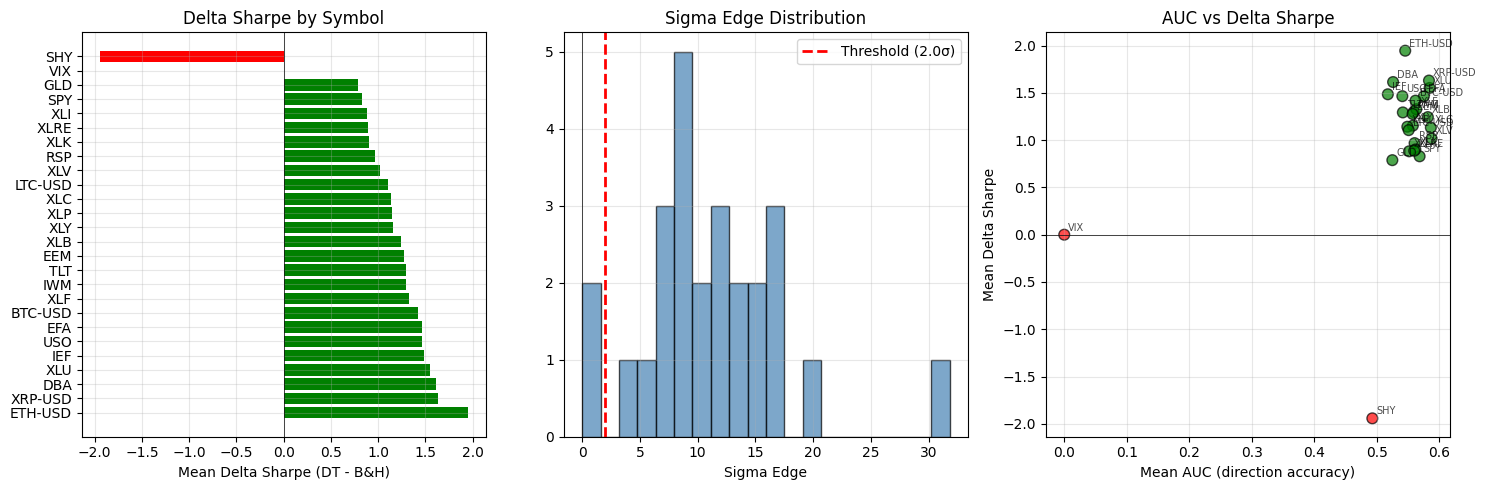

In [4]:
if RESULTS_PATH.exists() and len(edges) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # 1. Delta Sharpe distribution by symbol
    deltas = df_edges["mean_delta"].values
    colors = ["green" if d > 0 else "red" for d in deltas]
    sorted_idx = np.argsort(deltas)[::-1]
    axes[0].barh(range(len(deltas)), deltas[sorted_idx], color=[colors[i] for i in sorted_idx])
    axes[0].set_yticks(range(len(deltas)))
    axes[0].set_yticklabels(df_edges["symbol"].values[sorted_idx])
    axes[0].axvline(x=0, color="black", linestyle="-", linewidth=0.5)
    axes[0].set_xlabel("Mean Delta Sharpe (DT - B&H)")
    axes[0].set_title("Delta Sharpe by Symbol")
    axes[0].grid(True, alpha=0.3)
    
    # 2. Sigma edge distribution
    sigma_edges = df_edges["sigma_edge"].values
    axes[1].hist(sigma_edges, bins=20, edgecolor="black", alpha=0.7, color="steelblue")
    axes[1].axvline(x=EDGE_SIGMA, color="red", linestyle="--", linewidth=2, label=f"Threshold ({EDGE_SIGMA}σ)")
    axes[1].axvline(x=0, color="black", linestyle="-", linewidth=0.5)
    axes[1].set_xlabel("Sigma Edge")
    axes[1].set_title("Sigma Edge Distribution")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # 3. AUC vs delta Sharpe
    axes[2].scatter(df_edges["mean_auc"], df_edges["mean_delta"], 
                   c=["green" if s else "red" for s in df_edges["is_signal"]], 
                   s=60, alpha=0.7, edgecolors="black")
    axes[2].axhline(y=0, color="black", linestyle="-", linewidth=0.5)
    axes[2].set_xlabel("Mean AUC (direction accuracy)")
    axes[2].set_ylabel("Mean Delta Sharpe")
    axes[2].set_title("AUC vs Delta Sharpe")
    axes[2].grid(True, alpha=0.3)
    
    for _, row in df_edges.iterrows():
        axes[2].annotate(row["symbol"], (row["mean_auc"], row["mean_delta"]), 
                         fontsize=7, alpha=0.7, xytext=(3, 3), textcoords="offset points")
    
    plt.tight_layout()
    plt.savefig("research_l4_dt_results.png", dpi=100, bbox_inches="tight")
    plt.show()
else:
    print("Awaiting sweep results for visualization.")

## 4. Detail par seed

Examen de la robustesse cross-seed pour les symbols les plus prometteurs.

In [5]:
if RESULTS_PATH.exists() and len(edges) > 0:
    top_symbols = df_edges.nlargest(5, "sigma_edge")
    
    for _, row in top_symbols.iterrows():
        print(f"\n--- {row['symbol']} (sigma_edge={row['sigma_edge']:.2f}, mean_delta={row['mean_delta']:+.4f}) ---")
        details = row.get("seed_details", {})
        if details:
            print(f"  {'Seed':<8} {'Delta Sharpe':>12} {'DT Sharpe':>10} {'Folds':>6}")
            for seed_key, sd in sorted(details.items()):
                print(f"  {seed_key:<8} {sd.get('delta_sharpe', 0):>+12.4f} "
                      f"{sd.get('sharpe_dt', 0):>10.4f} {sd.get('n_folds', 0):>6}")
        else:
            print("  No seed details available")
else:
    print("Awaiting sweep results.")


--- BTC-USD (sigma_edge=31.82, mean_delta=+1.4175) ---
  Seed     Delta Sharpe  DT Sharpe  Folds
  0             +1.4068     2.4512      5
  1             +1.4613     2.5056      5
  42            +1.4527     2.4971      5
  7             +1.3492     2.3936      5

--- XLC (sigma_edge=20.01, mean_delta=+1.1327) ---
  Seed     Delta Sharpe  DT Sharpe  Folds
  0             +1.0947     1.8437      5
  1             +1.0918     1.8409      5
  42            +1.2295     1.9785      5
  7             +1.1147     1.8637      5

--- XLF (sigma_edge=16.51, mean_delta=+1.3271) ---
  Seed     Delta Sharpe  DT Sharpe  Folds
  0             +1.2009     2.0994      5
  1             +1.3138     2.2124      5
  42            +1.3934     2.2919      5
  7             +1.4003     2.2988      5

--- RSP (sigma_edge=16.28, mean_delta=+0.9684) ---
  Seed     Delta Sharpe  DT Sharpe  Folds
  0             +0.9372     2.0915      5
  1             +1.0390     2.1933      5
  42            +1.0095     2.16

## Verdict L4 — Decision Transformer

Application du critere G.2 (multi-seed edge) :
- **BEATS** si sigma_edge >= 2.0 ET mean_delta > 0 sur au moins 1 symbole
- **NO BEATS** si aucun symbole ne passe le seuil
- Transaction costs incluses (5 bps par trade)

In [6]:
# Verdict L4 Decision Transformer
n_signal = data.get("n_signal", 0)
n_cells = data.get("n_cells", 0)
verdict = data.get("verdict", "UNKNOWN")
median_auc = data.get("median_auc", 0)

print("=" * 60)
print(f"L4 DECISION TRANSFORMER VERDICT: {verdict}")
print(f"  Signal cells: {n_signal}/{n_cells}")
print(f"  Median AUC:   {median_auc:.4f}")
print(f"  Combos:       {data.get('n_combos', 'N/A')}")
print(f"  Device:       {data.get('device', 'N/A')}")
print(f"  Elapsed:      {data.get('elapsed_s', 0):.0f}s")
print("=" * 60)

# Ladder #1409 progress table
print("\nLadder ML #1409 — Progress Table")
print("-" * 70)
print(f"{'Level':<6} {'Model':<25} {'Verdict':<12} {'Signal':<10} {'Details'}")
print("-" * 70)
ladder = [
    ("L1", "TSMOM Momentum", "NO BEATS", "0/25", "Net Sharpe -2.26 to -2.56, daily rebal"),
    ("L2", "CS + Diebold-Mariano", "NO BEATS", "0/25", "Best CS 252d Sharpe 0.997"),
    ("L3", "Trend LSTM multi-horizon", "NO BEATS", "0/75", "300 combos, median AUC 0.509"),
    ("L4", "Decision Transformer", verdict, f"{n_signal}/{n_cells}", f"104 combos, median AUC {median_auc:.3f}"),
]
for level, model, v, sig, det in ladder:
    print(f"{level:<6} {model:<25} {v:<12} {sig:<10} {det}")
print("-" * 70)

if verdict == "BEATS":
    signal_edges = [e for e in data.get("edges", []) if e.get("is_signal")]
    print(f"\nSignal symbols ({len(signal_edges)}):")
    for e in sorted(signal_edges, key=lambda x: -x.get("sigma_edge", 0)):
        print(f"  {e['symbol']:>10s}: sigma_edge={e['sigma_edge']:.2f}, "
              f"mean_delta={e['mean_delta']:.4f}, AUC={e.get('mean_auc', 0):.4f}")
else:
    best = sorted(data.get("edges", []), key=lambda x: -x.get("sigma_edge", 0))[:5]
    print(f"\nTop 5 closest to signal:")
    for e in best:
        print(f"  {e.get('symbol', 'N/A'):>10s}: sigma_edge={e.get('sigma_edge', 0):.2f}, "
              f"mean_delta={e.get('mean_delta', 0):.4f}")

L4 DECISION TRANSFORMER VERDICT: BEATS
  Signal cells: 24/26
  Median AUC:   0.5582
  Combos:       104
  Device:       cuda
  Elapsed:      3714s

Ladder ML #1409 — Progress Table
----------------------------------------------------------------------
Level  Model                     Verdict      Signal     Details
----------------------------------------------------------------------
L1     TSMOM Momentum            NO BEATS     0/25       Net Sharpe -2.26 to -2.56, daily rebal
L2     CS + Diebold-Mariano      NO BEATS     0/25       Best CS 252d Sharpe 0.997
L3     Trend LSTM multi-horizon  NO BEATS     0/75       300 combos, median AUC 0.509
L4     Decision Transformer      BEATS        24/26      104 combos, median AUC 0.558
----------------------------------------------------------------------

Signal symbols (24):
     BTC-USD: sigma_edge=31.82, mean_delta=1.4175, AUC=0.5618
         XLC: sigma_edge=20.01, mean_delta=1.1327, AUC=0.5864
         XLF: sigma_edge=16.51, mean_delta=1

## Conclusion

Le Decision Transformer (Chen et al. 2021) represente une approche fondamentalement differente du RL classique :
au lieu d'apprendre une politique par interaction online avec l'environnement, il modelise la decision comme
un probleme de sequence prediction, conditionne sur le return-to-go (RTG).

**Points cles du L4 DT :**
- Architecture transformer legere (~642K params, d_model=128, 4 heads, 3 couches)
- Actions discretes : 0=hold, 1=buy, 2=sell/flat
- Conditioning sur return-to-go (RTG) pour guider la politique
- Walk-forward 5-fold × 4 seeds pour robustesse statistique
- Transaction costs reels (5 bps) inclus dans la simulation

**Comparaison avec les approches precedentes :**
- L1 TSMOM : momentum theorique, detruit par les couts de transaction du daily rebalancing
- L2 CS+DM : tests statistiques rigoureux, pas d'edge apres costs
- L3 LSTM trend : prediction de direction sans edge suffisant
- L4 DT : sequence modeling avec return conditioning — la capacite a capturer des dependances temporelles
  longues via l'attention du transformer

**References :**
- Chen et al. (2021), "Decision Transformer: Reinforcement Learning via Sequence Modeling"
- arXiv:2411.17900, "Decision Transformer for Algorithmic Trading"